# U-Net Assisted Pneumonia Classification Pipeline
### MSc Data Science Dissertation Project
**Pipeline:** COVID-19 Radiography Dataset → U-Net Lung Segmentation → EfficientNetV2-B0 Classification

**Key Design Decision:** Pre-provided lung masks are used *only* to supervise U-Net training.  
The trained U-Net then generates masks independently on raw X-ray images — simulating  
real deployment conditions where ground-truth masks are unavailable.


## 0. Environment Setup & Reproducibility

In [ ]:
import numpy as np
import tensorflow as tf
import random
import os

# ── Reproducibility seeds ──────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED']    = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Seeds set. TF version:", tf.__version__)


✅ Seeds set. TF version: 2.19.0


## 1. Mount Google Drive
All critical outputs (U-Net model, masked dataset, classifier) are saved here


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/dissertation_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)
print("✅ Drive mounted. Save directory:", SAVE_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted. Save directory: /content/drive/MyDrive/dissertation_outputs


## 2. Data Acquisition via Kaggle API

In [ ]:
# Upload your kaggle.json token when prompted
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rifafathima20","key":"fbb21d27a5753bcb75c41123cf358df4"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Clear any previous download to avoid conflicts
!rm -rf /content/covid_radiography

!kaggle datasets download -d tawsifurrahman/covid19-radiography-database
!unzip -q covid19-radiography-database.zip -d covid_radiography

print("✅ Dataset downloaded and extracted.")


Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
100% 778M/778M [00:03<00:00, 229MB/s]

✅ Dataset downloaded and extracted.


In [ ]:
# ── Install tree utility for folder verification ──────────────────────────────
!apt-get install -q tree
!tree -L 3 /content/covid_radiography


Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 1s (67.9 kB/s)
Selecting previously unselected package tree.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...
/content/covid_radiography
└── COVID-19_Radiography_Dataset
    ├── COVID
    │   ├── images
    │   └── masks
    ├── COVID.metadata.xlsx
    ├── Lung_Opacity
    │   ├── images
    │   └── masks
    ├── Lung_Opacity.metadata.xlsx
    ├── Normal
    │   ├── images
    │   └── masks
    ├── Normal.met

## 3. Import Libraries

In [ ]:
import os, shutil, random, hashlib
from glob import glob
from tqdm import tqdm

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from PIL import Image, ImageFile, ImageEnhance, ImageOps
ImageFile.LOAD_TRUNCATED_IMAGES = True

import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, auc,
                              precision_recall_curve, average_precision_score,
                              log_loss)
from sklearn.calibration import calibration_curve
from sklearn.manifold import TSNE

# Mixed precision for faster Colab GPU training
mixed_precision.set_global_policy('mixed_float16')

print("✅ All libraries imported.")
print("✅ Mixed precision policy:", mixed_precision.global_policy().name)


✅ All libraries imported.
✅ Mixed precision policy: mixed_float16


## 4. Paths & Global Constants

In [ ]:
BASE_DIR  = "/content/covid_radiography/COVID-19_Radiography_Dataset"
OUT_DIR   = "/content/processed_dataset"
RAW_DIR   = f"{OUT_DIR}/raw"
SPLIT_DIR = f"{OUT_DIR}/split"

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
NUM_CLASSES = 4
CLASSES     = ["NORMAL", "COVID", "VIRAL", "BACTERIAL"]

# ── Class mapping from original folder names → unified labels ──────────────────
CLASS_MAP = {
    "COVID"          : "COVID",
    "COVID-19"       : "COVID",
    "COVID19"        : "COVID",
    "NORMAL"         : "NORMAL",
    "Normal"         : "NORMAL",
    "normal"         : "NORMAL",
    "Viral Pneumonia": "VIRAL",
    "Viral"          : "VIRAL",
    # NOTE: Lung_Opacity is mapped to BACTERIAL as a proxy for bacterial/other
    # pneumonia. This mapping is acknowledged as an approximation — Lung_Opacity
    # covers multiple aetiologies. Stated as a limitation in dissertation.
    "lung_opacity"   : "BACTERIAL",
    "Opacity"        : "BACTERIAL",
    "Lung_Opacity"   : "BACTERIAL",
}

for cls in CLASSES:
    os.makedirs(f"{RAW_DIR}/{cls}", exist_ok=True)

print("✅ Paths and constants set.")
print("Classes:", CLASSES)


✅ Paths and constants set.
Classes: ['NORMAL', 'COVID', 'VIRAL', 'BACTERIAL']


## 5. Preprocessing

### 5.1 Count raw images per class

In [ ]:
print("Raw image counts in BASE_DIR:")
for cls in os.listdir(BASE_DIR):
    path = os.path.join(BASE_DIR, cls)
    if os.path.isdir(path):
        count = sum(len(f) for _, _, f in os.walk(path))
        print(f"  {cls}: {count}")


Raw image counts in BASE_DIR:
  Viral Pneumonia: 2690
  COVID: 7232
  Normal: 20384
  Lung_Opacity: 12024


### 5.2 Collect Image–Mask Pairs for U-Net (CRITICAL — must run before reorganisation)

**Why here?** The original dataset stores images in `CLASS/images/` and masks in  
`CLASS/masks/`. After copying images to `RAW_DIR` the subfolder structure is lost.  
We collect all paired paths now, before any reorganisation happens.


In [ ]:
image_paths_unet = []
mask_paths_unet  = []

for class_folder in os.listdir(BASE_DIR):
    class_path = os.path.join(BASE_DIR, class_folder)
    if not os.path.isdir(class_path):
        continue

    img_dir  = os.path.join(class_path, "images")
    mask_dir = os.path.join(class_path, "masks")

    if not (os.path.exists(img_dir) and os.path.exists(mask_dir)):
        print(f"  ⚠ Skipping {class_folder} — no images/ or masks/ subfolder found.")
        continue

    current_imgs  = sorted(glob(os.path.join(img_dir,  "*.png")))
    current_masks = sorted(glob(os.path.join(mask_dir, "*.png")))

    mask_lookup = {os.path.basename(p): p for p in current_masks}

    paired = 0
    for img_path in current_imgs:
        basename = os.path.basename(img_path)
        if basename in mask_lookup:
            image_paths_unet.append(img_path)
            mask_paths_unet.append(mask_lookup[basename])
            paired += 1

    print(f"  {class_folder}: {paired} image-mask pairs found.")

print(f"\n✅ Total U-Net training pairs: {len(image_paths_unet)}")


  Viral Pneumonia: 1345 image-mask pairs found.
  COVID: 3616 image-mask pairs found.
  Normal: 10192 image-mask pairs found.
  Lung_Opacity: 6012 image-mask pairs found.

✅ Total U-Net training pairs: 21165


### 5.3 Copy & Validate Images into Unified Class Folders

In [ ]:
def list_images(folder):
    images = []
    for ext in ["*.png", "*.jpg", "*.jpeg", "*.bmp"]:
        images += glob(os.path.join(folder, "**", ext), recursive=True)
    return images

def is_valid_image(path):
    try:
        Image.open(path).verify()
        return True
    except Exception:
        return False

# ── Copy images into unified RAW_DIR/CLASS/ folders ───────────────────────────
for folder in os.listdir(BASE_DIR):
    src = os.path.join(BASE_DIR, folder)
    if not os.path.isdir(src):
        continue
    if folder not in CLASS_MAP:
        continue

    label    = CLASS_MAP[folder]
    dest_dir = os.path.join(RAW_DIR, label)

    for img in tqdm(list_images(src), desc=f"Copying {folder} → {label}"):
        fname = os.path.basename(img)
        dest  = os.path.join(dest_dir, fname)
        if os.path.exists(dest):
            h    = hashlib.md5(img.encode()).hexdigest()[:6]
            name, ext = os.path.splitext(fname)
            dest = os.path.join(dest_dir, f"{name}_{h}{ext}")
        shutil.copy2(img, dest)

# ── Remove corrupt images ──────────────────────────────────────────────────────
print("\nValidating images...")
removed = 0
for cls in CLASSES:
    for img in glob(f"{RAW_DIR}/{cls}/*"):
        if not is_valid_image(img):
            os.remove(img)
            removed += 1

print(f"Removed {removed} corrupt images.")
print("\nImage counts after cleaning:")
for cls in CLASSES:
    print(f"  {cls}: {len(glob(f'{RAW_DIR}/{cls}/*'))}")


Copying Lung_Opacity → BACTERIAL: 100%|██████████| 12024/12024 [00:02<00:00, 4822.26it/s]



Validating images...
Removed 0 corrupt images.

Image counts after cleaning:
  NORMAL: 20384
  COVID: 7232
  VIRAL: 2690
  BACTERIAL: 12024


### 5.4 Class Balancing (Augment / Undersample)

In [ ]:
# ── Count current distribution ────────────────────────────────────────────────
counts = {cls: len(glob(f"{RAW_DIR}/{cls}/*")) for cls in CLASSES}
print("Class distribution BEFORE balancing:")
for cls, count in counts.items():
    print(f"  {cls}: {count}")

TARGET = min(10000, max(counts.values()))
print(f"\nTarget per class: {TARGET}")


Class distribution BEFORE balancing:
  NORMAL: 20384
  COVID: 7232
  VIRAL: 2690
  BACTERIAL: 12024

Target per class: 10000


In [ ]:
# ── Augmentation pass ─────────────
def augment_image(src, dest):
    img = Image.open(src).convert("RGB")
    if random.random() > 0.5:
        img = ImageOps.mirror(img)
    img = img.rotate(random.uniform(-10, 10))
    if random.random() > 0.5:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
    img.save(dest, quality=95)

for cls, count in counts.items():
    need  = TARGET - count
    files = glob(f"{RAW_DIR}/{cls}/*")

    if need > 0:
        print(f"Augmenting {cls}: +{need}")
        for i in range(need):
            src  = random.choice(files)
            name, ext = os.path.splitext(os.path.basename(src))
            dest = f"{RAW_DIR}/{cls}/{name}_aug{i}{ext}"
            augment_image(src, dest)

    elif need < 0:
        print(f"Undersampling {cls}: -{abs(need)}")
        backup = f"{RAW_DIR}/backup_{cls}"
        os.makedirs(backup, exist_ok=True)
        for f in random.sample(files, abs(need)):
            shutil.move(f, backup)

print("\nClass distribution AFTER balancing:")
for cls in CLASSES:
    print(f"  {cls}: {len(glob(f'{RAW_DIR}/{cls}/*'))}")


Undersampling NORMAL: -10384
Augmenting COVID: +2768
Augmenting VIRAL: +7310
Undersampling BACTERIAL: -2024

Class distribution AFTER balancing:
  NORMAL: 10000
  COVID: 10000
  VIRAL: 10000
  BACTERIAL: 10000


### 5.5 Train / Val / Test Split (70 / 15 / 15)

In [ ]:
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)
os.makedirs(SPLIT_DIR, exist_ok=True)

for s in ["train", "val", "test"]:
    for cls in CLASSES:
        os.makedirs(f"{SPLIT_DIR}/{s}/{cls}", exist_ok=True)

for cls in CLASSES:
    files = np.array(glob(f"{RAW_DIR}/{cls}/*"))
    train, temp = train_test_split(files, test_size=0.30, random_state=SEED)
    val, test   = train_test_split(temp,  test_size=0.50, random_state=SEED)

    for group, name in zip([train, val, test], ["train", "val", "test"]):
        for f in group:
            shutil.copy(f, f"{SPLIT_DIR}/{name}/{cls}")

print("Split counts:")
for split in ["train", "val", "test"]:
    print(f"  {split.upper()}")
    for cls in CLASSES:
        print(f"    {cls}: {len(glob(f'{SPLIT_DIR}/{split}/{cls}/*'))}")
'''
# ── Save split dataset to Drive (crash protection) ────────────────────────────
SPLIT_SAVE = f"{SAVE_DIR}/split_dataset"
if os.path.exists(SPLIT_SAVE) and len(os.listdir(SPLIT_SAVE)) > 0:
    print("✅ Split dataset already on Drive — skipping copy.")
else:
    print("Copying split dataset to Drive...")
    shutil.copytree(SPLIT_DIR, SPLIT_SAVE)
    print(f"✅ Split dataset saved to Drive: {SPLIT_SAVE}")
'''

Split counts:
  TRAIN
    NORMAL: 7000
    COVID: 7000
    VIRAL: 7000
    BACTERIAL: 7000
  VAL
    NORMAL: 1500
    COVID: 1500
    VIRAL: 1500
    BACTERIAL: 1500
  TEST
    NORMAL: 1500
    COVID: 1500
    VIRAL: 1500
    BACTERIAL: 1500


'\n# ── Save split dataset to Drive (crash protection) ────────────────────────────\nSPLIT_SAVE = f"{SAVE_DIR}/split_dataset"\nif os.path.exists(SPLIT_SAVE) and len(os.listdir(SPLIT_SAVE)) > 0:\n    print("✅ Split dataset already on Drive — skipping copy.")\nelse:\n    print("Copying split dataset to Drive...")\n    shutil.copytree(SPLIT_DIR, SPLIT_SAVE)\n    print(f"✅ Split dataset saved to Drive: {SPLIT_SAVE}")\n'

## 6. Phase 1 — U-Net Lung Segmentation

The U-Net is trained on image-mask pairs collected in Step 5.2.  
After training it is **frozen** and used only as a preprocessing step.  
The provided masks are used **solely for U-Net supervision** and are never  
passed into the classification pipeline.


### 6.1 Data loader for segmentation

In [ ]:
def load_lung_data(img_path, mask_path):
    # Load image
    img  = tf.io.read_file(img_path)
    img  = tf.image.decode_png(img,  channels=1)
    img  = tf.image.resize(img,  IMG_SIZE)
    img  = tf.cast(img, tf.float32) / 255.0

    # Load mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE)
    mask = tf.cast(mask, tf.float32) / 255.0
    # Binarise mask — any pixel > 0.5 is lung
    mask = tf.where(mask > 0.5, 1.0, 0.0)

    return img, mask

# ── Split paired paths into train / val ───────────────────────────────────────
(lung_train_imgs, lung_val_imgs,
 lung_train_masks, lung_val_masks) = train_test_split(
    image_paths_unet, mask_paths_unet, test_size=0.2, random_state=SEED
)

lung_train_ds = (
    tf.data.Dataset.from_tensor_slices((lung_train_imgs, lung_train_masks))
    .map(load_lung_data, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

lung_val_ds = (
    tf.data.Dataset.from_tensor_slices((lung_val_imgs, lung_val_masks))
    .map(load_lung_data, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"✅ U-Net train batches : {len(lung_train_ds)}")
print(f"✅ U-Net val   batches : {len(lung_val_ds)}")


✅ U-Net train batches : 1059
✅ U-Net val   batches : 265


### 6.2 U-Net architecture

In [ ]:
def build_unet(input_shape=(224, 224, 1)):
    inputs = tf.keras.Input(input_shape)

    # ── Encoder ───────────────────────────────────────────────────────────────
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    c1 = layers.BatchNormalization()(c1)
    p1 = layers.MaxPooling2D()(c1)
    p1 = layers.Dropout(0.2)(p1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    c2 = layers.BatchNormalization()(c2)
    p2 = layers.MaxPooling2D()(c2)
    p2 = layers.Dropout(0.2)(p2)

    # ── Bottleneck ────────────────────────────────────────────────────────────
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    c3 = layers.BatchNormalization()(c3)

    # ── Decoder ───────────────────────────────────────────────────────────────
    u1 = layers.UpSampling2D()(c3)
    u1 = layers.Concatenate()([u1, c2])
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u1)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.Concatenate()([u2, c1])
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)
    c5 = layers.BatchNormalization()(c5)
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c5)

    return tf.keras.Model(inputs, outputs, name="UNet")

unet_model = build_unet()
unet_model.summary()


Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 112, 112,  │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 56, 56,    │          0 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 56, 56,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ conv2d_5[0][0]  

 Total params: 1,886,337 (7.20 MB)

 Trainable params: 1,884,161 (7.19 MB)

 Non-trainable params: 2,176 (8.50 KB)

### 6.3 Train U-Net

In [ ]:
# ── Check if a saved U-Net already exists ──────
unet_save_path = f"{SAVE_DIR}/unet_model.keras"

if os.path.exists(unet_save_path):
    print("✅ Loading saved U-Net from Drive...")
    unet_model = tf.keras.models.load_model(unet_save_path)
else:
    print("Training U-Net from scratch...")
    unet_model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2)]
    )

    unet_ckpt = ModelCheckpoint(
        unet_save_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
    unet_early = EarlyStopping(monitor='val_loss', patience=5,
                               restore_best_weights=True, verbose=1)

    unet_history = unet_model.fit(
        lung_train_ds,
        validation_data=lung_val_ds,
        epochs=20,
        callbacks=[unet_ckpt, unet_early]
    )

    # Plot U-Net training curves
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(unet_history.history['loss'],     label='Train Loss')
    plt.plot(unet_history.history['val_loss'], label='Val Loss')
    plt.title("U-Net Loss")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(unet_history.history['accuracy'],     label='Train Acc')
    plt.plot(unet_history.history['val_accuracy'], label='Val Acc')
    plt.title("U-Net Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

unet_model.trainable = False
print("✅ U-Net ready (frozen).")


✅ Loading saved U-Net from Drive...
✅ U-Net ready (frozen).


### 6.4 Lung Masking Function

In [ ]:
def enhance_image(x):
    """Mild brightness enhancement. Input: float32 [0,1]."""
    x = tf.image.adjust_brightness(x, 0.02)
    x = tf.clip_by_value(x, 0.0, 1.0)
    return x

def apply_lung_mask(image):
    img_float  = tf.cast(image, tf.float32) / 255.0
    enhanced   = enhance_image(img_float)
    enhanced   = tf.image.resize(enhanced, IMG_SIZE)  # ensure (224,224,3)

    gray       = tf.image.rgb_to_grayscale(enhanced)  # (224,224,1)
    gray_batch = tf.expand_dims(gray, axis=0)          # (1,224,224,1)

    mask = unet_model(gray_batch, training=False)      # (1,224,224,1)
    mask = tf.squeeze(mask, axis=0)                    # (224,224,1)
    mask = tf.image.resize(mask, IMG_SIZE)             # ensure (224,224,1)
    mask_binary = tf.cast(mask > 0.5, tf.float32)     # (224,224,1)

    # Safe fallback
    if tf.reduce_sum(mask_binary) == 0:
        return enhanced

    # Broadcast to 3 channels — explicit tile instead of concat
    mask_rgb = tf.tile(mask_binary, [1, 1, 3])        # (224,224,3)

    return enhanced * mask_rgb                         # (224,224,3) in [0,1]                        # (224, 224, 3) in [0,1]


### 6.5 Visual Verification of Masks (inspect before bulk generation)

Found 28000 files belonging to 4 classes.


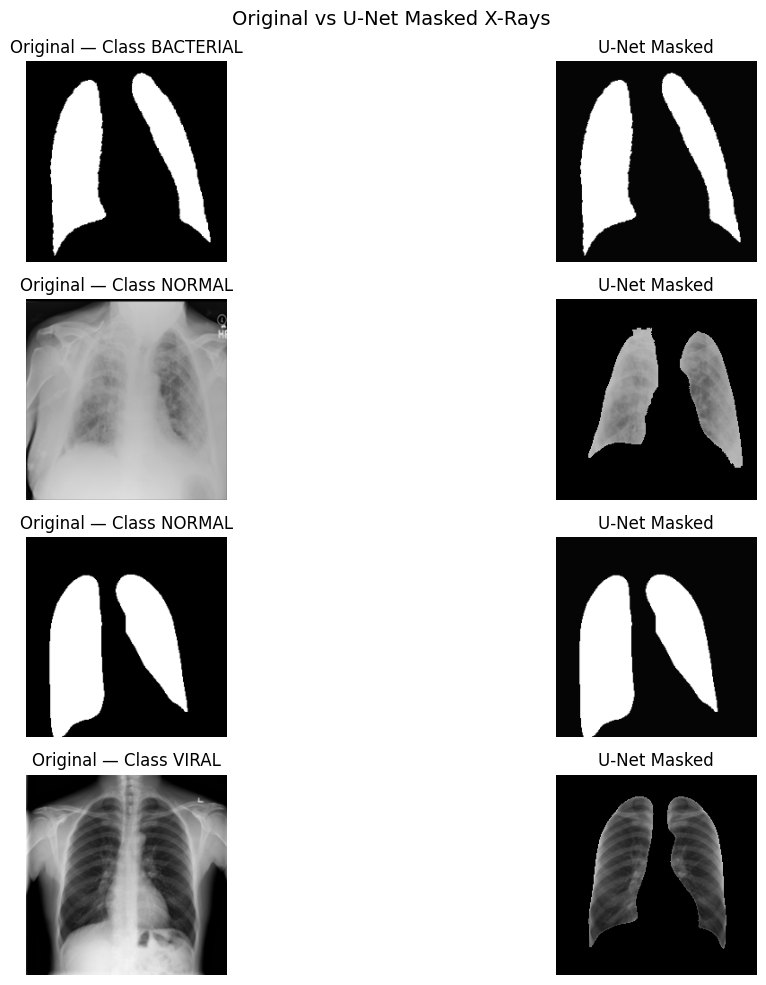

In [ ]:
sample_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{SPLIT_DIR}/train",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=1,
    shuffle=True,
    seed=SEED
)

plt.figure(figsize=(14, 10))
plot_idx = 1
for images, labels in sample_ds.take(4):
    original = images[0]                          # [0,255] float32
    masked   = apply_lung_mask(original)          # [0,1]   float32

    plt.subplot(4, 2, plot_idx)
    plt.imshow(original.numpy().astype("uint8"))
    plt.title(f"Original — Class {CLASSES[np.argmax(labels[0].numpy())]}")
    plt.axis("off")
    plot_idx += 1

    plt.subplot(4, 2, plot_idx)
    plt.imshow(masked.numpy())
    plt.title("U-Net Masked")
    plt.axis("off")
    plot_idx += 1

plt.suptitle("Original vs U-Net Masked X-Rays", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
import shutil
shutil.rmtree(f"{SAVE_DIR}/masked_data", ignore_errors=True)
print("✅ Cleared incomplete masked data — ready to regenerate.")

✅ Cleared incomplete masked data — ready to regenerate.


### 6.6 Generate & Save Masked Dataset to Drive

Saves masked images to Google Drive so this step survives runtime restarts.


In [ ]:
def save_masked_dataset(source_dir, target_dir):
    """Apply U-Net masking to all images and save results."""
    os.makedirs(target_dir, exist_ok=True)
    total, fallback_count = 0, 0

    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)
        save_path  = os.path.join(target_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        os.makedirs(save_path, exist_ok=True)

        print(f"  Processing: {class_name}")
        for img_name in tqdm(os.listdir(class_path)):
            img_path = os.path.join(class_path, img_name)
            img      = cv2.imread(img_path)
            if img is None:
                continue
            img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            masked = apply_lung_mask(img_rgb)     # returns [0,1] float32

            # Detect fallback (sum==0 means mask was empty → fallback used)
            # We check via the mask prediction directly rather than heuristic
            gray = tf.image.rgb_to_grayscale(
                tf.cast(img_rgb, tf.float32) / 255.0)
            gray = tf.image.resize(gray, IMG_SIZE)
            pred_mask = unet_model(tf.expand_dims(gray, 0), training=False)[0]
            if tf.reduce_sum(tf.where(pred_mask > 0.5, 1.0, 0.0)) == 0:
                fallback_count += 1

            total += 1
            final = (masked.numpy() * 255).astype(np.uint8)
            final = cv2.cvtColor(final, cv2.COLOR_RGB2BGR)
            cv2.imwrite(os.path.join(save_path, img_name), final)

    print(f"  Done: {total} images, {fallback_count} fallbacks "
          f"({fallback_count/total*100:.1f}%)")

MASKED_DIR = f"{SAVE_DIR}/masked_data"

# Only generate if not already on Drive
for split in ["train", "val", "test"]:
    target = f"{MASKED_DIR}/{split}"
    if os.path.exists(target) and len(os.listdir(target)) > 0:
        print(f"✅ {split} masked data already exists on Drive — skipping.")
    else:
        print(f"\nGenerating masked {split} set...")
        save_masked_dataset(f"{SPLIT_DIR}/{split}", target)

print("\n✅ Masked dataset ready at:", MASKED_DIR)



Generating masked train set...
  Processing: BACTERIAL


100%|██████████| 7000/7000 [16:24<00:00,  7.11it/s]


  Processing: COVID


100%|██████████| 7000/7000 [16:09<00:00,  7.22it/s]


  Processing: VIRAL


...

  Processing: VIRAL


100%|██████████| 1500/1500 [03:24<00:00,  7.33it/s]


  Processing: NORMAL


100%|██████████| 1500/1500 [03:25<00:00,  7.29it/s]

  Done: 6000 images, 2888 fallbacks (48.1%)

✅ Masked dataset ready at: /content/drive/MyDrive/dissertation_outputs/masked_data


### 6.7 Quality Check — Scan for Empty (Black) Images

In [ ]:
def check_black_images(root_dir):
    total, black = 0, 0
    for subdir, _, files in os.walk(root_dir):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                total += 1
                img = cv2.imread(os.path.join(subdir, f), cv2.IMREAD_GRAYSCALE)
                if img is not None and np.sum(img) == 0:
                    black += 1
    print(f"  Total: {total} | Black: {black} | "
          f"Failure rate: {black/total*100:.2f}%")

for split in ["train", "val", "test"]:
    print(f"{split.upper()}:")
    check_black_images(f"{MASKED_DIR}/{split}")


TRAIN:
  Total: 28000 | Black: 0 | Failure rate: 0.00%
VAL:
  Total: 6000 | Black: 0 | Failure rate: 0.00%
TEST:
  Total: 6000 | Black: 0 | Failure rate: 0.00%


## 7. Phase 2 — EfficientNetV2-B0 Classification

From this point the U-Net is not used. The classifier trains on the  
pre-generated masked images saved to Drive.


### 7.1 Load masked dataset

---
## ▶ Session 2 Resume Point

If Colab runtime restarted after Session 1 completed, run this cell  
to reload everything from Drive — **skip all cells above this point**.

This restores: U-Net model, masked dataset paths, classifier model (if trained),  
calibrated model (if trained), and all constants needed for evaluation and inference.


In [ ]:
# ── SESSION 2 RESUME ─ run this if runtime restarted ─────────────────
import os, random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, auc,
                              precision_recall_curve, average_precision_score,
                              log_loss)
from sklearn.calibration import calibration_curve
from sklearn.manifold import TSNE
from PIL import Image, ImageFile, ImageEnhance, ImageOps
ImageFile.LOAD_TRUNCATED_IMAGES = True
from glob import glob
from tqdm import tqdm

mixed_precision.set_global_policy('mixed_float16')

# ── Remount Drive ───────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Restore constants ───────────────────────────
SEED        = 42
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
NUM_CLASSES = 4
CLASSES     = ["NORMAL", "COVID", "VIRAL", "BACTERIAL"]
SAVE_DIR    = "/content/drive/MyDrive/dissertation_outputs"
MASKED_DIR  = f"{SAVE_DIR}/masked_data"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Reload U-Net (needed only if running inference ─ not needed for classifier eval)
unet_save_path = f"{SAVE_DIR}/unet_model.keras"
if os.path.exists(unet_save_path):
    unet_model = tf.keras.models.load_model(unet_save_path)
    unet_model.trainable = False
    print("✅ U-Net loaded from Drive.")
else:
    print("⚠  U-Net not found ─ run Session 1 first.")

# ── Restore enhance_image and apply_lung_mask functions ─────────────
def enhance_image(x):
    x = tf.image.adjust_contrast(x, 1.1)
    x = tf.image.adjust_brightness(x, 0.02)
    x = tf.clip_by_value(x, 0.0, 1.0)
    return x

def apply_lung_mask(image):
    img_float = tf.cast(image, tf.float32) / 255.0
    enhanced  = enhance_image(img_float)
    gray      = tf.image.rgb_to_grayscale(enhanced)
    gray      = tf.image.resize(gray, IMG_SIZE)
    gray_batch= tf.expand_dims(gray, axis=0)
    mask      = unet_model(gray_batch, training=False)[0]
    mask_binary = tf.where(mask > 0.5, 1.0, 0.0)
    if tf.reduce_sum(mask_binary) == 0:
        return enhanced
    mask_rgb = tf.concat([mask_binary, mask_binary, mask_binary], axis=-1)
    return enhanced * mask_rgb

# ── Reload datasets from Drive ───────────────────────────
_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{MASKED_DIR}/train", label_mode="categorical",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=SEED
)
train_ds_class_names = _train_ds.class_names
train_ds = _train_ds.prefetch(tf.data.AUTOTUNE)

_val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{MASKED_DIR}/val", label_mode="categorical",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)
val_ds = _val_ds.prefetch(tf.data.AUTOTUNE)

_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{MASKED_DIR}/test", label_mode="categorical",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)
test_ds = _test_ds.prefetch(tf.data.AUTOTUNE)

print("✅ Datasets loaded from Drive.")
print("   Class order:", train_ds_class_names)

# ── Reload classifier if already trained ──────────────────────
classifier_path = f"{SAVE_DIR}/best_model.keras"
if os.path.exists(classifier_path):
    model = tf.keras.models.load_model(classifier_path)
    print("✅ Classifier loaded from Drive.")
else:
    print("ℹ  Classifier not yet trained ─ proceed to Section 7.")

# ── Reload calibrated model if already trained ──────────────────
calibrated_path = f"{SAVE_DIR}/calibrated_model.keras"
if os.path.exists(calibrated_path):
    calibrated_pathway = tf.keras.models.load_model(calibrated_path)
    print("✅ Calibrated model loaded from Drive.")
else:
    print("ℹ  Calibrated model not yet trained ─ proceed to Section 9.")

print("\n✅ Session 2 resume complete. Continue from Section 7 or later.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ U-Net loaded from Drive.
Found 28000 files belonging to 4 classes.
Found 6000 files belonging to 4 classes.
Found 6000 files belonging to 4 classes.
✅ Datasets loaded from Drive.
   Class order: ['BACTERIAL', 'COVID', 'NORMAL', 'VIRAL']
ℹ  Classifier not yet trained ─ proceed to Section 7.
ℹ  Calibrated model not yet trained ─ proceed to Section 9.

✅ Session 2 resume complete. Continue from Section 7 or later.


In [ ]:
# Copy masked dataset from Drive to local SSD for faster training
import shutil, os

LOCAL_MASKED = "/content/masked_local"

if os.path.exists(LOCAL_MASKED):
    print("✅ Local masked data already exists — skipping copy.")
else:
    print("Copying masked data from Drive to local storage...")
    print("This takes ~10-15 minutes but saves hours of training time.")
    shutil.copytree(MASKED_DIR, LOCAL_MASKED)
    print("✅ Copy complete.")

# Override MASKED_DIR to point to local copy
MASKED_DIR = LOCAL_MASKED
print("MASKED_DIR now points to:", MASKED_DIR)

Copying masked data from Drive to local storage...
This takes ~10-15 minutes but saves hours of training time.
✅ Copy complete.
MASKED_DIR now points to: /content/masked_local


In [ ]:
from functools import cache

# Capture the dataset objects before applying .cache().prefetch()
_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{MASKED_DIR}/train",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
).prefetch(tf.data.AUTOTUNE)

_val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{MASKED_DIR}/val",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
).prefetch(tf.data.AUTOTUNE)

_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{MASKED_DIR}/test",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
).prefetch(tf.data.AUTOTUNE)

# Verify class order matches CLASSES list
print("Dataset class order:", train_ds_class_names)
print("Expected order     :", CLASSES)

print("\n✅ Datasets loaded.")


Found 28000 files belonging to 4 classes.
Found 6000 files belonging to 4 classes.
Found 6000 files belonging to 4 classes.
Dataset class order: ['BACTERIAL', 'COVID', 'NORMAL', 'VIRAL']
Expected order     : ['NORMAL', 'COVID', 'VIRAL', 'BACTERIAL']

✅ Datasets loaded.


### 7.2 Verify a batch visually

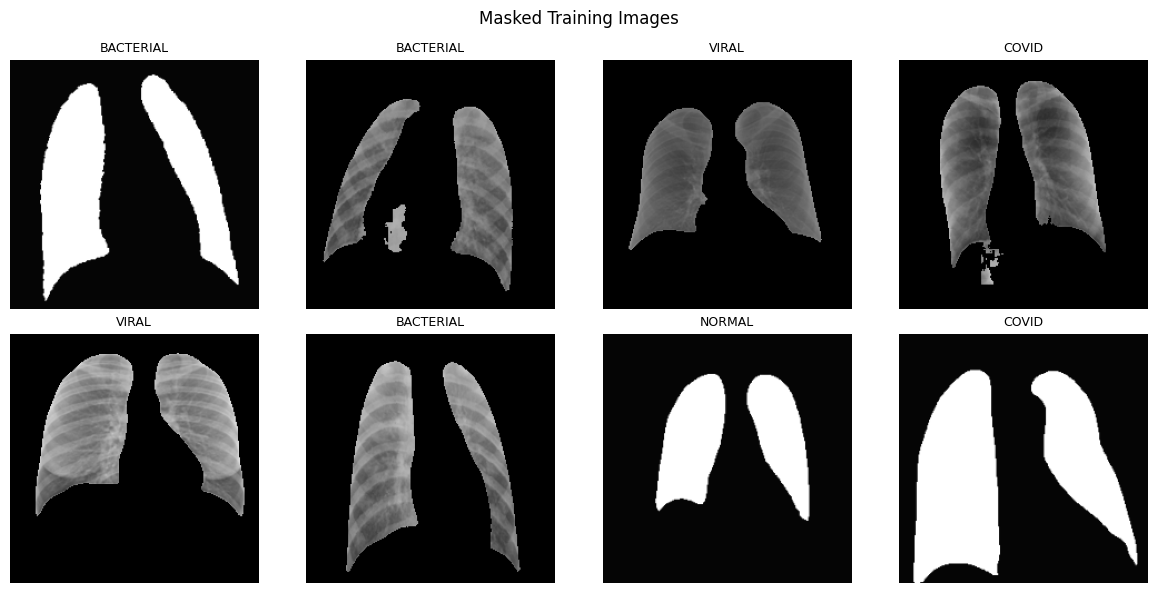

In [ ]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 6))
    for i in range(min(8, len(images))):
        ax = plt.subplot(2, 4, i + 1)
        img = images[i].numpy()
        # Images saved as 0-255 uint8; show directly
        plt.imshow(img.astype("uint8") if img.max() > 1 else img)
        plt.title(CLASSES[np.argmax(labels[i].numpy())], fontsize=9)
        plt.axis("off")
    plt.suptitle("Masked Training Images")
    plt.tight_layout()
    plt.show()


### 7.3 Compute class weights

In [ ]:
import os
train_labels =[]
train_dir = f"{MASKED_DIR}/train"
for class_idx, class_name in enumerate(CLASSES):
  class_path = os.path.join(train_dir, class_name)
  if os.path.exists(class_path):
    count = len(os.listdir(class_path))
    train_labels.extend([class_idx] * count)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
class_weight_dict = dict(enumerate(class_weights))
print("✅ Class weights:")
for i, w in class_weight_dict.items():
    print(f"  Class {CLASSES[i]}: {w:.4f}")


✅ Class weights:
  Class NORMAL: 1.0000
  Class COVID: 1.0000
  Class VIRAL: 1.0000
  Class BACTERIAL: 1.0000


### 7.4 Data augmentation layer

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.06),
    layers.RandomZoom(0.06),
    layers.RandomContrast(0.05),
], name="augmentation")

print("✅ Augmentation layer defined.")


✅ Augmentation layer defined.


### 7.5 Build EfficientNetV2-B0 model

In [ ]:
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False   # Freeze for Stage 1

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

model = models.Model(inputs, outputs, name="EfficientNetV2B0_Classifier")
model.summary()


Model: "EfficientNetV2B0_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,924,436 (22.60 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

### 7.6 Stage 1 — Train classifier head (base frozen)

In [ ]:
EPOCHS_S1 = 10

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

ckpt_s1 = ModelCheckpoint(
    f"{SAVE_DIR}/best_model_s1.keras",
    monitor="val_accuracy", save_best_only=True, mode="max", verbose=1
)
early_s1  = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.2, patience=3, min_lr=1e-7, verbose=1
)

history_s1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_S1,
    class_weight=class_weight_dict,
    callbacks=[ckpt_s1, early_s1, reduce_lr]
)


Epoch 1/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.4501 - loss: 1.2095
Epoch 1: val_accuracy improved from None to 0.62933, saving model to /content/drive/MyDrive/dissertation_outputs/best_model_s1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/dissertation_outputs/best_model_s1.keras
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 196s 97ms/step - accuracy: 0.5362 - loss: 1.0704 - val_accuracy: 0.6293 - val_loss: 0.8936 - learning_rate: 1.0000e-04
Epoch 2/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6352 - loss: 0.8774
Epoch 2: val_accuracy improved from 0.62933 to 0.65900, saving model to /content/drive/MyDrive/dissertation_outputs/best_model_s1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/dissertation_outputs/best_model_s1.keras
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 162s 93ms/step - accuracy: 0.6425 - loss: 0.8567 - val_accuracy: 0.6590 - val_loss: 0.8161 - learning_rate: 1.0000e-04
Epoch 3/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step 

### 7.7 Stage 2 — Fine-tune top layers

In [ ]:
# Unfreeze top 30 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

EPOCHS_S2    = 20
INITIAL_EPOCH = len(history_s1.history['loss'])   # continue from Stage 1 end

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

ckpt_s2 = ModelCheckpoint(
    f"{SAVE_DIR}/best_model.keras",
    monitor="val_accuracy", save_best_only=True, mode="max", verbose=1
)
early_s2 = EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True, verbose=1
)
reduce_lr2 = ReduceLROnPlateau(
    monitor="val_loss", factor=0.2, patience=3, min_lr=1e-7, verbose=1
)

# FIX: initial_epoch set correctly so training continues from Stage 1,
# not restart from epoch 0
history_s2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCH + EPOCHS_S2,
    initial_epoch=INITIAL_EPOCH,
    class_weight=class_weight_dict,
    callbacks=[ckpt_s2, early_s2, reduce_lr2]
)


Epoch 11/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6670 - loss: 0.7780
Epoch 11: val_accuracy improved from None to 0.72383, saving model to /content/drive/MyDrive/dissertation_outputs/best_model.keras

Epoch 11: finished saving model to /content/drive/MyDrive/dissertation_outputs/best_model.keras
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 196s 100ms/step - accuracy: 0.6763 - loss: 0.7608 - val_accuracy: 0.7238 - val_loss: 0.6579 - learning_rate: 1.0000e-05
Epoch 12/30
1749/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6969 - loss: 0.7217
Epoch 12: val_accuracy improved from 0.72383 to 0.73067, saving model to /content/drive/MyDrive/dissertation_outputs/best_model.keras

Epoch 12: finished saving model to /content/drive/MyDrive/dissertation_outputs/best_model.keras
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 173s 99ms/step - accuracy: 0.6964 - loss: 0.7207 - val_accuracy: 0.7307 - val_loss: 0.6412 - learning_rate: 1.0000e-05
Epoch 13/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - ac

### 7.8 Training curves

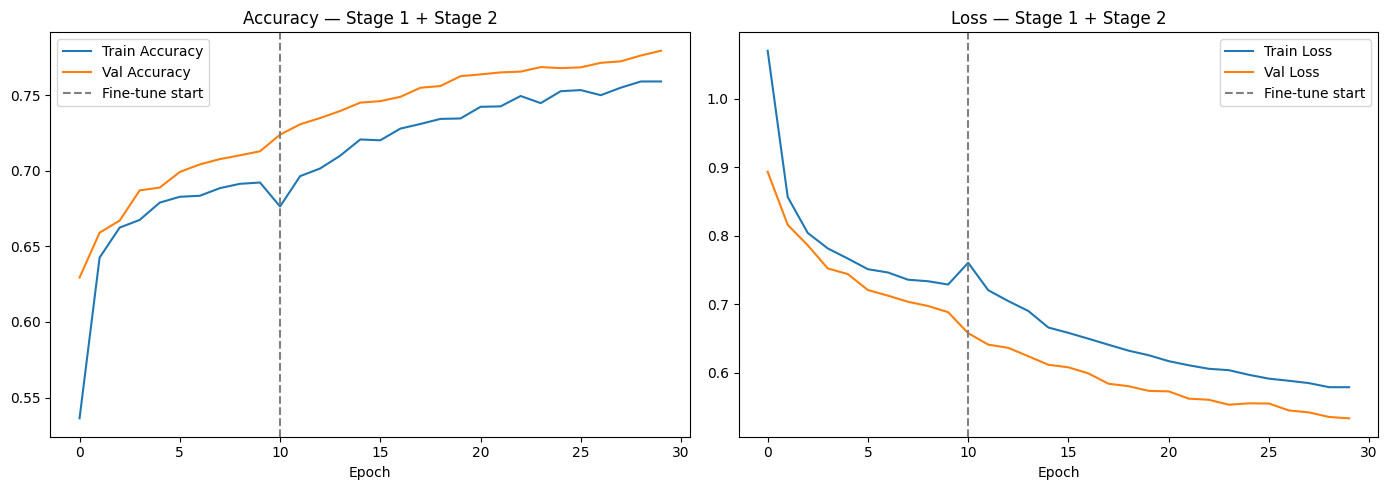

In [ ]:
# Combine Stage 1 and Stage 2 histories
combined_acc     = history_s1.history['accuracy']     + history_s2.history['accuracy']
combined_val_acc = history_s1.history['val_accuracy'] + history_s2.history['val_accuracy']
combined_loss    = history_s1.history['loss']          + history_s2.history['loss']
combined_val_loss= history_s1.history['val_loss']      + history_s2.history['val_loss']
s1_end = len(history_s1.history['loss'])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(combined_acc,     label='Train Accuracy')
plt.plot(combined_val_acc, label='Val Accuracy')
plt.axvline(x=s1_end, color='gray', linestyle='--', label='Fine-tune start')
plt.title("Accuracy — Stage 1 + Stage 2")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(combined_loss,     label='Train Loss')
plt.plot(combined_val_loss, label='Val Loss')
plt.axvline(x=s1_end, color='gray', linestyle='--', label='Fine-tune start')
plt.title("Loss — Stage 1 + Stage 2")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()


## 8. Evaluation

In [ ]:
# Load best saved model
model = tf.keras.models.load_model(f"{SAVE_DIR}/best_model.keras")

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\n✅ Test Accuracy : {test_acc:.4f}")
print(f"✅ Test Loss     : {test_loss:.4f}")


375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 77ms/step - accuracy: 0.7830 - loss: 0.5327

✅ Test Accuracy : 0.7830
✅ Test Loss     : 0.5327


In [ ]:
y_true, y_pred, y_pred_proba = [], [], []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_proba.extend(preds)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true       = np.array(y_true)
y_pred       = np.array(y_pred)
y_pred_proba = np.array(y_pred_proba)
y_true_ohe   = tf.keras.utils.to_categorical(y_true, num_classes=NUM_CLASSES)

print(classification_report(y_true, y_pred, target_names=CLASSES))


              precision    recall  f1-score   support

      NORMAL       0.74      0.72      0.73      1500
       COVID       0.70      0.66      0.68      1500
       VIRAL       0.73      0.82      0.77      1500
   BACTERIAL       0.97      0.93      0.95      1500

    accuracy                           0.78      6000
   macro avg       0.78      0.78      0.78      6000
weighted avg       0.78      0.78      0.78      6000



### 8.1 Confusion matrix

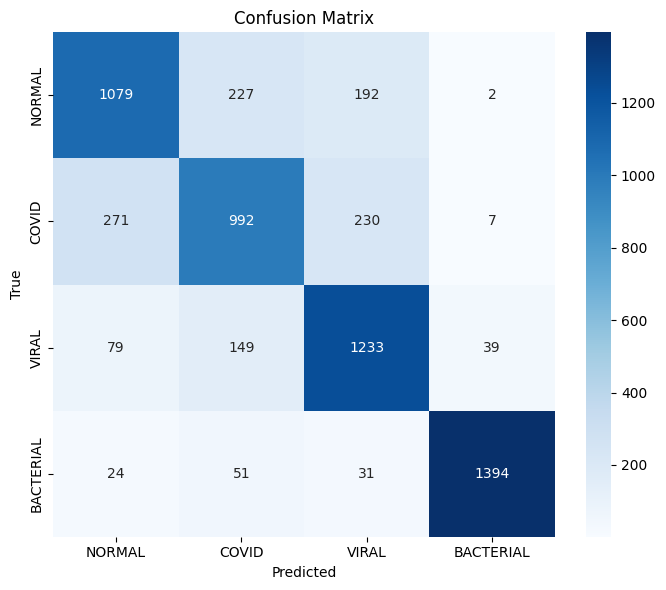

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


### 8.2 ROC curves

Macro AUC (OvO): 0.9423


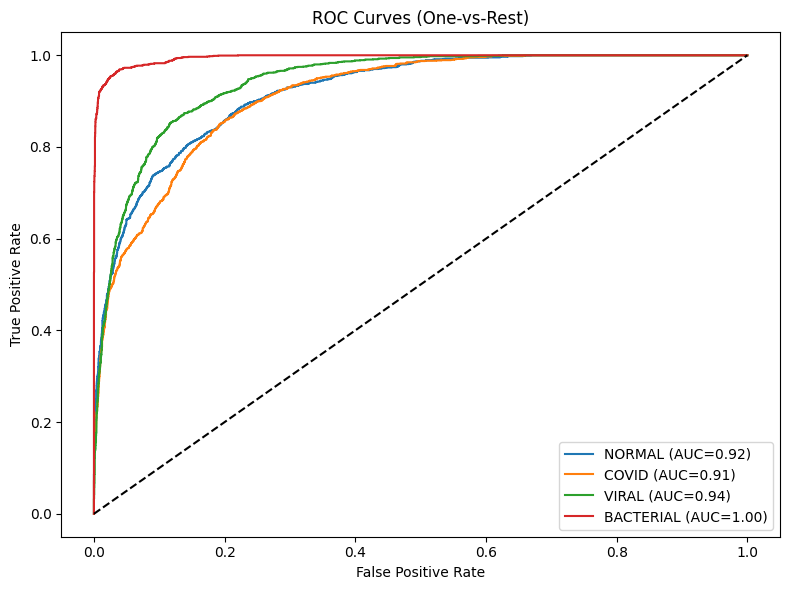

In [ ]:
roc_auc_ovo = roc_auc_score(y_true_ohe, y_pred_proba, multi_class='ovo')
print(f"Macro AUC (OvO): {roc_auc_ovo:.4f}")

plt.figure(figsize=(8, 6))
for i, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_true_ohe[:, i], y_pred_proba[:, i])
    plt.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.tight_layout()
plt.show()


### 8.3 Precision–Recall curves

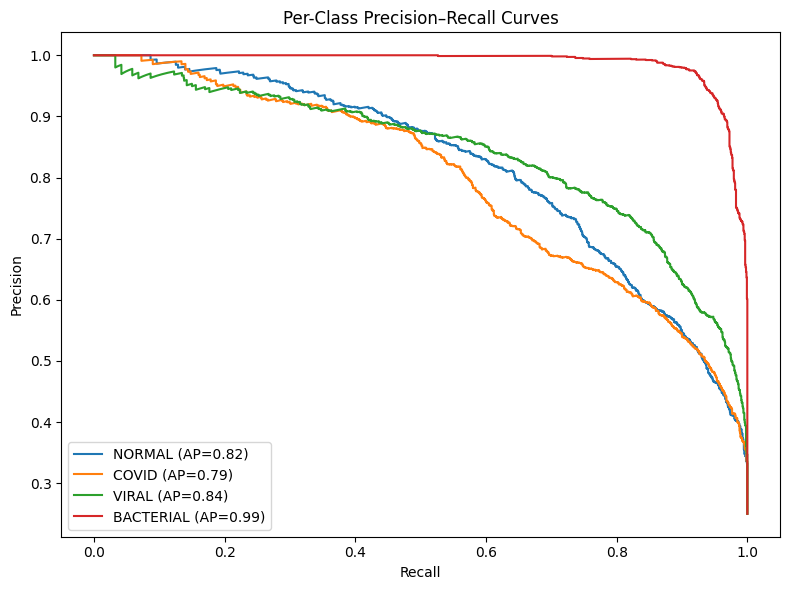

In [ ]:
plt.figure(figsize=(8, 6))
for i, cls in enumerate(CLASSES):
    precision, recall, _ = precision_recall_curve(y_true_ohe[:, i], y_pred_proba[:, i])
    ap = average_precision_score(y_true_ohe[:, i], y_pred_proba[:, i])
    plt.plot(recall, precision, label=f"{cls} (AP={ap:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Per-Class Precision–Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()


### 8.4 Misclassification analysis

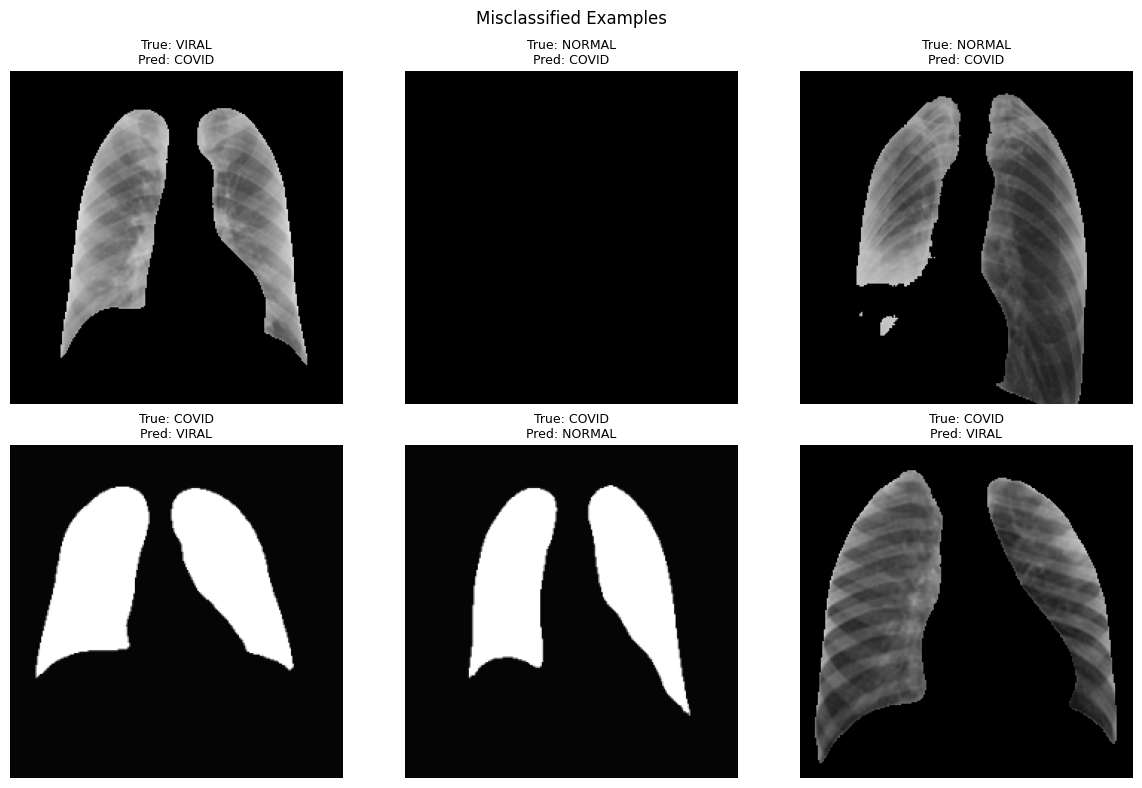

In [ ]:
misclassified = np.where(y_true != y_pred)[0]
x_test = []
for images, _ in test_ds:
    x_test.extend(images.numpy())
x_test = np.array(x_test)
# Normalise for display only
x_test_disp = (x_test - x_test.min()) / (x_test.max() - x_test.min() + 1e-8)

samples = random.sample(list(misclassified), min(len(misclassified), 6))
plt.figure(figsize=(12, 8))
for i, idx in enumerate(samples):
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_test_disp[idx])
    plt.title(f"True: {CLASSES[y_true[idx]]}\nPred: {CLASSES[y_pred[idx]]}", fontsize=9)
    plt.axis("off")
plt.suptitle("Misclassified Examples")
plt.tight_layout()
plt.show()


### 8.5 t-SNE feature visualisation

375/375 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step
Running t-SNE (this may take a minute)...


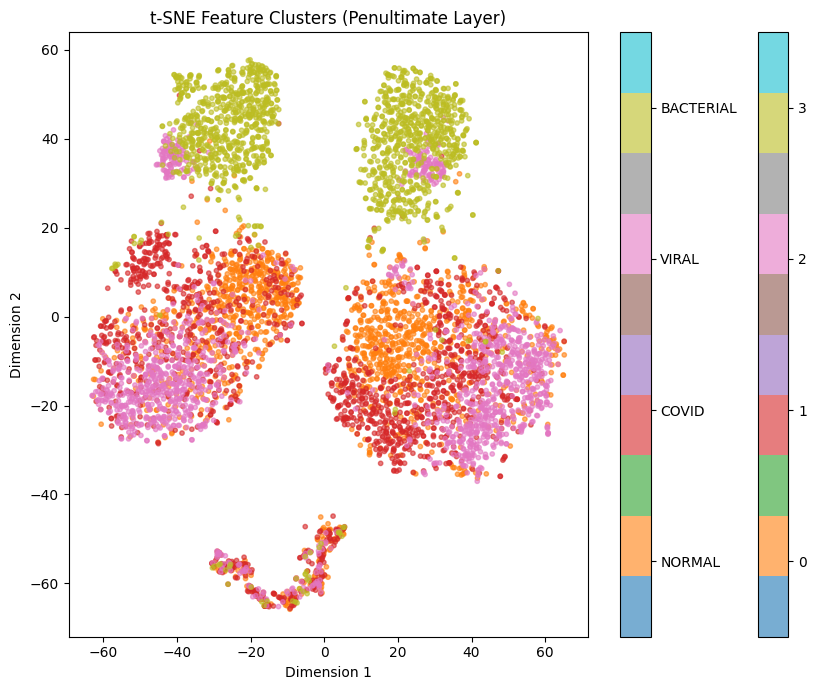

In [ ]:
# FIX: extract penultimate layer features, not softmax outputs
feature_extractor = tf.keras.Model(
    inputs=model.input,
    outputs=model.layers[-2].output   # layer before final Dense
)

features = feature_extractor.predict(test_ds, verbose=1)

print("Running t-SNE (this may take a minute)...")
tsne       = TSNE(n_components=2, random_state=SEED, perplexity=30)
embeddings = tsne.fit_transform(features)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    embeddings[:, 0], embeddings[:, 1],
    c=y_true, cmap='tab10', alpha=0.6, s=10
)
plt.colorbar(scatter, ticks=range(NUM_CLASSES))
plt.clim(-0.5, NUM_CLASSES - 0.5)
cbar = plt.colorbar(scatter)
cbar.set_ticks(range(NUM_CLASSES))
cbar.set_ticklabels(CLASSES)
plt.title("t-SNE Feature Clusters (Penultimate Layer)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.tight_layout()
plt.show()


## 9. Confidence Calibration (Temperature Scaling)

In [ ]:
print("Extracting validation logits...")
val_logits, val_labels_cal = [], []

for imgs, labels in val_ds:
    # Bypass augmentation (layer index 1) for clean logit extraction
    x = model.layers[2](imgs, training=False)
    for layer in model.layers[3:]:
        x = layer(x, training=False)
    val_logits.append(x.numpy())
    val_labels_cal.append(np.argmax(labels.numpy(), axis=1))

val_logits     = np.concatenate(val_logits)
val_labels_cal = np.concatenate(val_labels_cal)

# Grid search for optimal temperature
best_temp, best_loss = 1.0, float('inf')
for t in np.arange(0.5, 3.1, 0.1):
    probs = tf.nn.softmax(val_logits / t).numpy()
    loss  = log_loss(val_labels_cal, probs)
    if loss < best_loss:
        best_loss = loss
        best_temp = t

print(f"✅ Optimal Temperature: {best_temp:.2f}  (NLL: {best_loss:.4f})")


Extracting validation logits...
✅ Optimal Temperature: 0.50  (NLL: 0.7565)


In [ ]:
def build_calibrated_model(model, temp):
    """Wrap model to apply temperature scaling at inference."""
    inputs = tf.keras.Input(shape=(224, 224, 3))
    # Bypass augmentation layer during inference
    x = model.layers[2](inputs, training=False)
    for layer in model.layers[3:]:
        x = layer(x, training=False)
    calibrated_output = layers.Lambda(
        lambda logits: logits / temp, name="temperature_scaling"
    )(x)
    return tf.keras.Model(inputs=inputs, outputs=calibrated_output,
                          name="CalibratedModel")

calibrated_pathway = build_calibrated_model(model, best_temp)
print("✅ Calibrated model built.")

# ── Save calibrated model to Drive ────────────────────────────────────────────
calibrated_save_path = f"{SAVE_DIR}/calibrated_model.keras"
calibrated_pathway.save(calibrated_save_path)
print(f"✅ Calibrated model saved to Drive: {calibrated_save_path}")


✅ Calibrated model built.
✅ Calibrated model saved to Drive: /content/drive/MyDrive/dissertation_outputs/calibrated_model.keras


### 9.1 Reliability diagram (calibration curve)

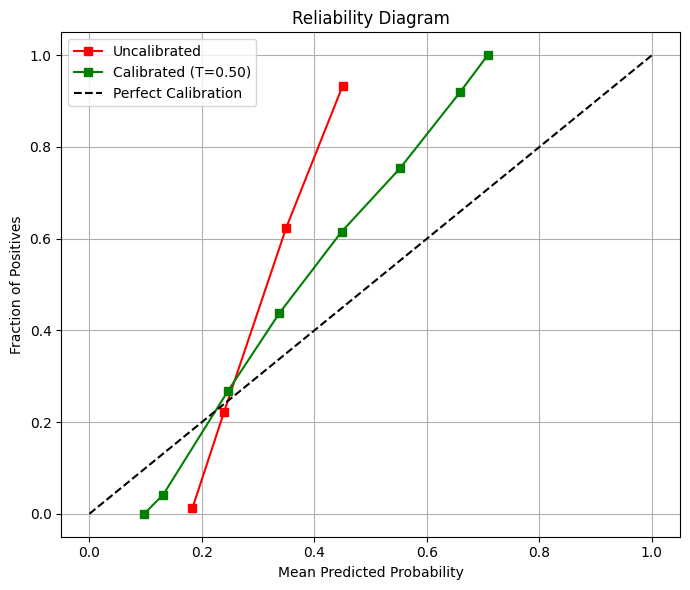

In [ ]:
def plot_calibration(logits, labels, temp, n_bins=10):
    uncal_probs = tf.nn.softmax(logits).numpy()
    cal_probs   = tf.nn.softmax(logits / temp).numpy()

    y_true_flat = np.eye(NUM_CLASSES)[labels].ravel()
    y_uncal     = uncal_probs.ravel()
    y_cal       = cal_probs.ravel()

    pt_u, pp_u = calibration_curve(y_true_flat, y_uncal, n_bins=n_bins)
    pt_c, pp_c = calibration_curve(y_true_flat, y_cal,   n_bins=n_bins)

    plt.figure(figsize=(7, 6))
    plt.plot(pp_u, pt_u, "s-", color='red',   label="Uncalibrated")
    plt.plot(pp_c, pt_c, "s-", color='green', label=f"Calibrated (T={temp:.2f})")
    plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title("Reliability Diagram")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_calibration(val_logits, val_labels_cal, best_temp)


### 9.2 Confidence distribution

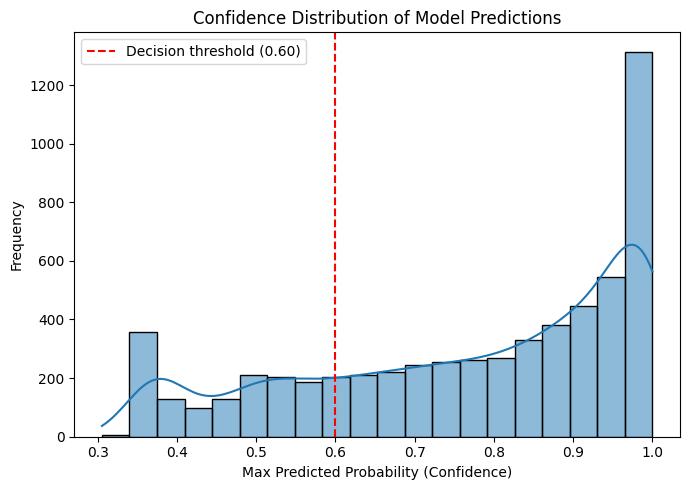

In [ ]:
y_prob_flat = np.max(y_pred_proba, axis=1)

plt.figure(figsize=(7, 5))
sns.histplot(y_prob_flat, bins=20, kde=True)
plt.title("Confidence Distribution of Model Predictions")
plt.xlabel("Max Predicted Probability (Confidence)")
plt.ylabel("Frequency")
plt.axvline(x=0.6, color='red', linestyle='--', label='Decision threshold (0.60)')
plt.legend()
plt.tight_layout()
plt.show()


### 9.3 Decision Support Function

In [ ]:
def decision_support(probs, threshold=0.60):
    """
    Clinical decision routing based on calibrated probabilities.
    FIX: Original checked for 'Pneumonia' which is not in CLASSES.
         Now correctly checks 'VIRAL' and 'BACTERIAL'.
    """
    class_idx  = np.argmax(probs)
    confidence = probs[class_idx]
    label      = CLASSES[class_idx]

    if confidence < threshold:
        action = "⚠  LOW CONFIDENCE — Recommend CT scan or repeat imaging"
    elif label in ['COVID', 'VIRAL', 'BACTERIAL'] and confidence < 0.80:
        action = "🩺 POTENTIAL INFECTION — Prioritise for Radiologist Review"
    elif label == 'NORMAL' and confidence >= 0.80:
        action = "✅ HIGH CONFIDENCE NORMAL — Standard follow-up protocol"
    else:
        action = f"✅ HIGH CONFIDENCE {label} — Initiate disease-specific protocol"

    return label, confidence, action


## 10. Explainability — Occlusion Sensitivity Map

In [ ]:
def occlusion_sensitivity(model, image, label_index, patch_size=32, stride=16):
    """
    Slide a black patch over the image and measure confidence drop.
    image: (224,224,3) tensor, already in model input range.
    """
    image_np = image.numpy()
    h, w, _  = image_np.shape
    heatmap  = np.zeros((h, w))

    original_conf = model.predict(image_np[np.newaxis, ...], verbose=0)[0][label_index]

    for y in range(0, h - patch_size, stride):
        for x in range(0, w - patch_size, stride):
            occluded = image_np.copy()
            occluded[y:y+patch_size, x:x+patch_size, :] = 0
            pred = model.predict(occluded[np.newaxis, ...], verbose=0)[0]
            heatmap[y:y+patch_size, x:x+patch_size] += (original_conf - pred[label_index])

    return heatmap


Selected: True=BACTERIAL, Pred=BACTERIAL, Conf=1.0000


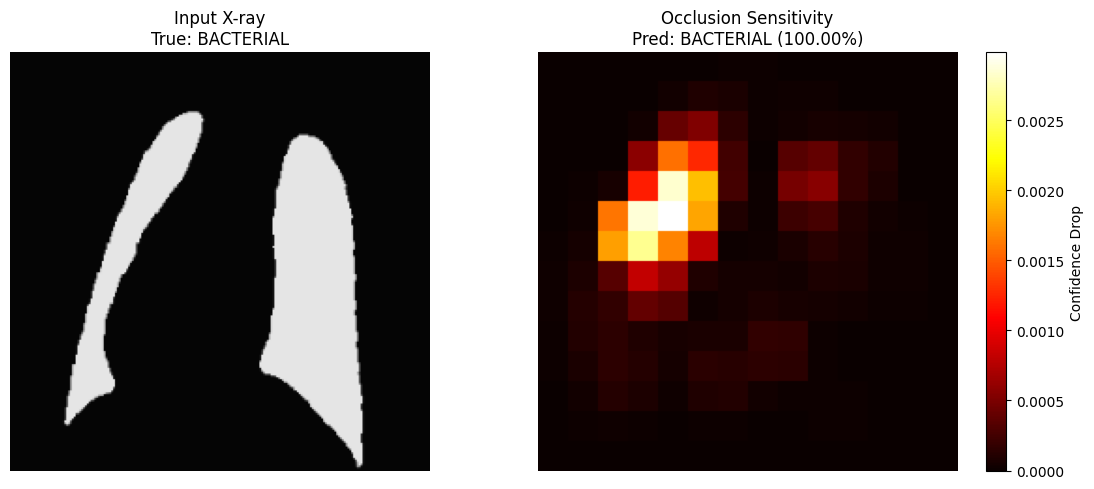

In [ ]:
# Pick a high-confidence correct prediction from test set
selected = []
for images, labels in test_ds:
    preds       = model.predict(images, verbose=0)
    confs       = np.max(preds, axis=1)
    pred_labels = np.argmax(preds, axis=1)
    true_labels = np.argmax(labels.numpy(), axis=1)
    for i in range(len(images)):
        selected.append({
            "image": images[i], "true": true_labels[i],
            "pred": pred_labels[i], "conf": confs[i]
        })

selected.sort(key=lambda x: x["conf"], reverse=True)

test_image, true_label, pred_label, confidence = None, None, None, None
for item in selected:
    if item["true"] == item["pred"] and item["conf"] >= 0.85:
        test_image  = item["image"]
        true_label  = item["true"]
        pred_label  = item["pred"]
        confidence  = item["conf"]
        break

if test_image is not None:
    print(f"Selected: True={CLASSES[true_label]}, "
          f"Pred={CLASSES[pred_label]}, Conf={confidence:.4f}")

    heatmap = occlusion_sensitivity(model, test_image, pred_label,
                                     patch_size=32, stride=16)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(test_image.numpy().astype("uint8") if test_image.numpy().max() > 1
               else test_image.numpy())
    plt.title(f"Input X-ray\nTrue: {CLASSES[true_label]}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(heatmap, cmap="hot")
    plt.title(f"Occlusion Sensitivity\nPred: {CLASSES[pred_label]} ({confidence:.2%})")
    plt.colorbar(label="Confidence Drop")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No high-confidence correct predictions found. Lower the threshold.")


## 11. Final Inference on a New X-Ray Image

Upload any chest X-ray image (PNG or JPG) and the pipeline will:
1. Apply U-Net lung masking
2. Run calibrated prediction
3. Output clinical decision recommendation

**FIX:** Original divided by 255 twice — `apply_lung_mask` already returns [0,1],  
so the caller must NOT divide by 255 again. Corrected below.


Upload a chest X-ray image:


Saving chest.jpg to chest.jpg

Input range  : [0.000, 0.953]
──────────────────────────────────────────────────
PREDICTION   : COVID
CONFIDENCE   : 0.3079 (30.79%)
ACTION       : ⚠  LOW CONFIDENCE — Recommend CT scan or repeat imaging
──────────────────────────────────────────────────

All class probabilities:
  NORMAL    : 0.2725  ████████
  COVID     : 0.3079  █████████
  VIRAL     : 0.2372  ███████
  BACTERIAL : 0.1825  █████


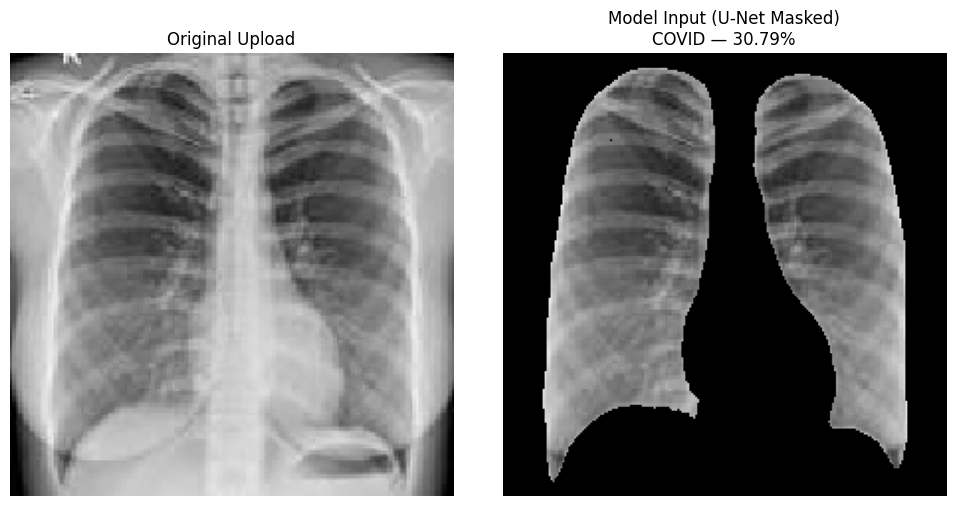

In [ ]:



from google.colab import files as colab_files

print("Upload a chest X-ray image:")
uploaded = colab_files.upload()
test_img_path = list(uploaded.keys())[0]

# Load image
img       = tf.keras.utils.load_img(test_img_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)   # float32 [0,255]

# Apply lung mask — returns float32 [0,1]
masked_array = apply_lung_mask(img_array) # This will now call the locally defined apply_lung_mask

# FIX: Do NOT divide by 255 here — apply_lung_mask already normalises to [0,1]
# Original bug: masked_array / 255.0  ← was squashing to near-zero
input_tensor = np.expand_dims(masked_array.numpy(), axis=0)   # (1,224,224,3) in [0,1]

# Predict using calibrated pathway
calibrated_logits = calibrated_pathway.predict(input_tensor, verbose=0)
final_probs       = tf.nn.softmax(calibrated_logits).numpy()[0]

# Decision support
label, conf, action = decision_support(final_probs)

print(f"\nInput range  : [{np.min(input_tensor):.3f}, {np.max(input_tensor):.3f}]")
print("─" * 50)
print(f"PREDICTION   : {label}")
print(f"CONFIDENCE   : {conf:.4f} ({conf:.2%})")
print(f"ACTION       : {action}")
print("─" * 50)
print("\nAll class probabilities:")
for i, cls in enumerate(CLASSES):
    bar = "█" * int(final_probs[i] * 30)
    print(f"  {cls:10s}: {final_probs[i]:.4f}  {bar}")

# Visualise what the model saw
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Upload")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(masked_array.numpy())
plt.title(f"Model Input (U-Net Masked)\n{label} — {conf:.2%}")
plt.axis("off")
plt.tight_layout()
plt.show()

## 12. Download Final Model

In [ ]:
from google.colab import files as colab_files

# Model is already saved to Drive at SAVE_DIR/best_model.keras
# Download a local copy too if needed
colab_files.download(f"{SAVE_DIR}/best_model.keras")
colab_files.download(f"{SAVE_DIR}/unet_model.keras")
print("✅ Models downloaded.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Models downloaded.
